In [4]:
print("Hello teen mental health analysis project")

Hello teen mental health analysis project


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Phase 1: Dataset Understanding  


Task 1 

Load the dataset

In [6]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

1.  Total number of rows and columns.

In [7]:
df.shape

(1200, 13)

2.  List all features.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140.4 KB


3.  Identify: 


○  Numerical columns

In [9]:
numerical_column = df.select_dtypes(include='number').columns

numerical_column

Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

○  Categorical columns

In [10]:
categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='str')

○  Target column : depression_label

# Phase 2: Data Cleaning 

Task 2


Perform data preprocessing: 

1.  Check missing values.

In [11]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

2.  Check duplicate records.

In [12]:
df.duplicated().sum()

np.int64(0)

3.  Handle inconsistent values.

In [13]:
for i in categorical_columns :
    unique_value = df[i].unique()
    print(unique_value)

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str
<ArrowStringArray>
['Instagram', 'TikTok', 'Both']
Length: 3, dtype: str
<ArrowStringArray>
['low', 'high', 'medium']
Length: 3, dtype: str


4.  Fix data types.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140.4 KB


In [15]:
df.sample(5)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
866,13,male,7.7,Instagram,4.4,2.0,3.09,1.0,high,8,7,8,1
637,16,male,2.0,TikTok,7.8,0.5,2.81,1.4,high,10,2,4,0
759,18,male,3.6,Instagram,4.7,2.5,2.73,1.2,medium,9,7,6,0
1042,18,male,4.2,Instagram,5.5,1.8,3.83,1.9,low,3,8,8,0
724,15,male,8.0,Instagram,4.7,0.6,3.01,1.8,medium,2,9,10,0


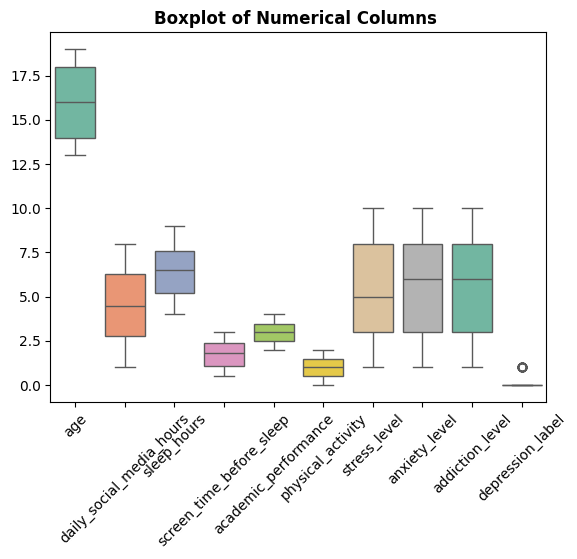

In [16]:

plt.Figure(figsize=(12,8))
sns.boxplot(data=df.select_dtypes(include='number'), palette='Set2' )
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Columns " , fontweight = 'bold')
plt.show()


# Phase 3: Exploratory Data Analysis

Univariate Analysis

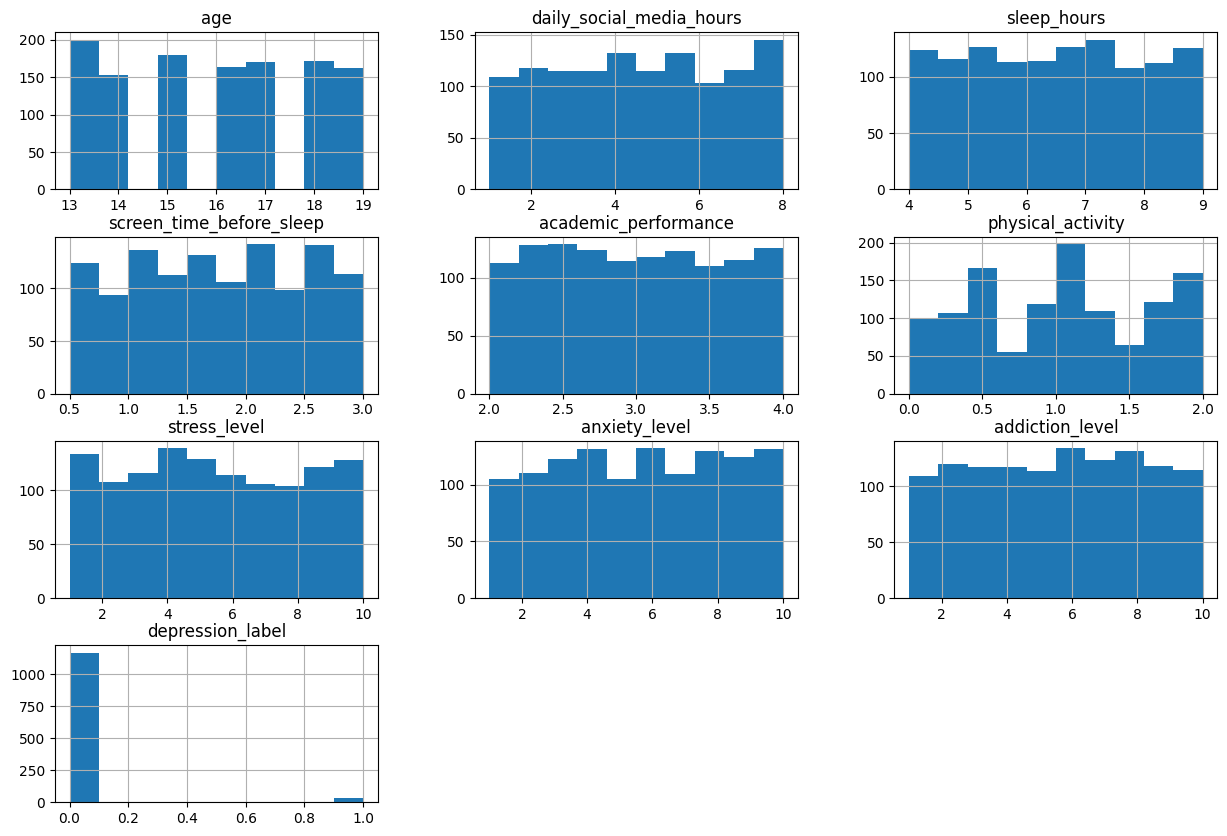

In [17]:
num_col = df.select_dtypes(include='number').columns
df[num_col].hist(figsize=(15,10))
plt.show()

**Explanation**

- Age is fairly balanced across 13–19 years, ensuring diverse representation.
- Most teens spend 3–8 hours/day on social media, indicating heavy digital engagement.
- Sleep duration clusters around 6–8 hours, which is within healthy range for most respondents — but depressed teens show significantly lower values.
- Stress and anxiety levels are widely spread (1–10), reflecting the diverse mental health landscape in the dataset.
- Physical activity varies greatly, with some teens reporting zero activity — a potential risk factor.
- The `depression_label` is highly imbalanced: ~1,169 non-depressed vs ~31 depressed, which must be addressed before any predictive modeling.

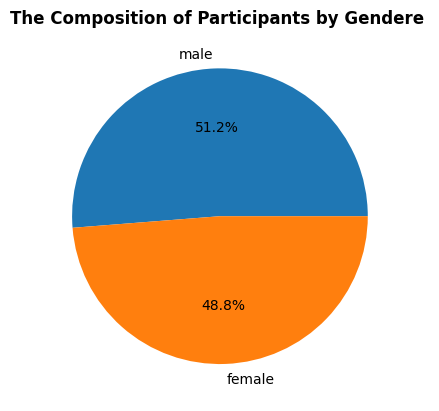

In [18]:
counts = df['gender'].value_counts()
plt.Figure(figsize=(4,4))
plt.pie(counts,labels=counts.index , autopct='%1.1f%%')
plt.title("The Composition of Participants by Gendere " , fontweight = 'bold')
plt.show()

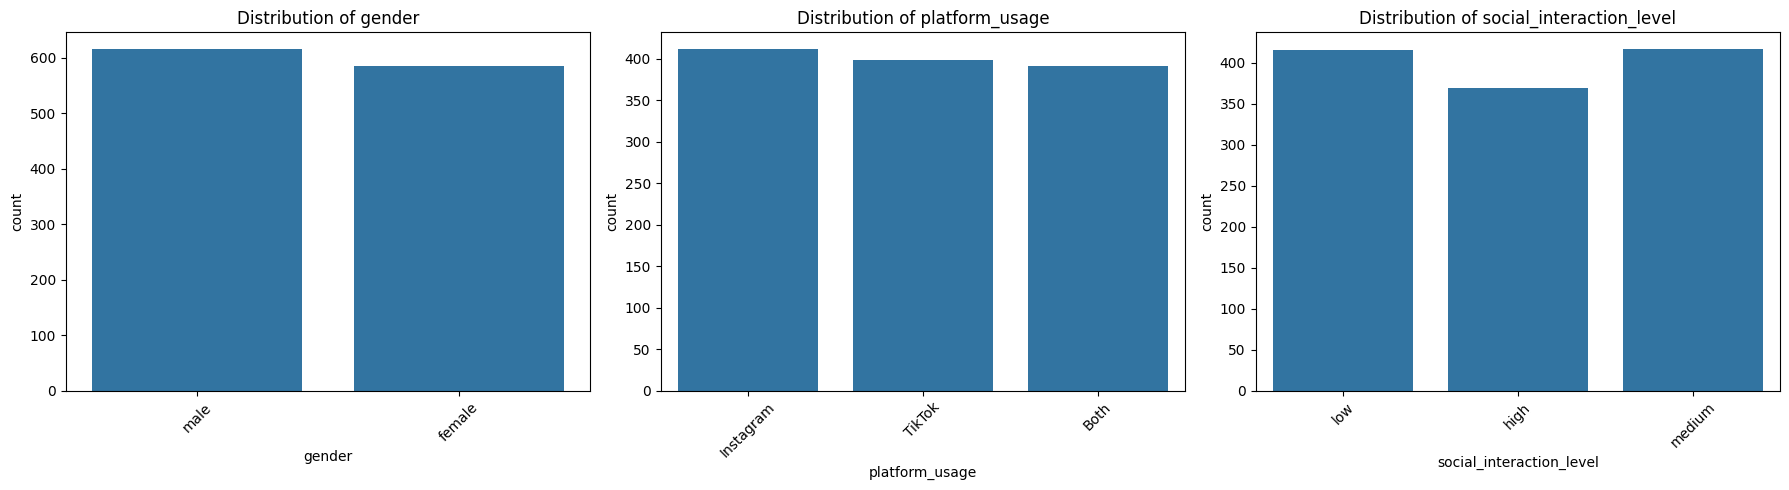

In [19]:
n_cols = 3
n_rows = (len(categorical_columns) + n_cols -1  ) // n_cols

fig , axes = plt.subplots(n_rows , n_cols, figsize= (18,5* n_rows))

axes = axes.flatten()

for i , col in enumerate(categorical_columns):
    sns.countplot(x=df[col] , ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis= 'x' , rotation= 45)

for j in range(i+1 , len(axes)):
        fig.delaxes(axes[j])


plt.tight_layout()
plt.show()




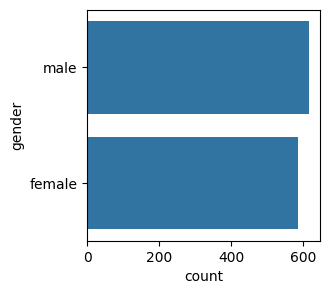

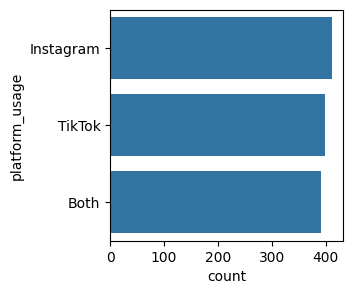

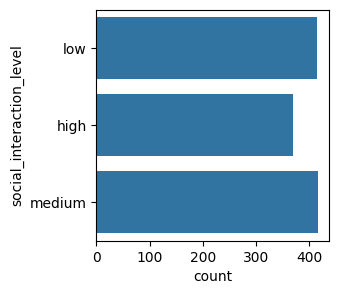

In [20]:
categorical_columns = df.select_dtypes(include=['object']).columns
for i in categorical_columns:
    plt.figure(figsize=(3,3))
    sns.countplot(df[i])
    plt.show()

**Explanation**

- **Platform usage** is roughly balanced across Instagram, TikTok, and Both, meaning the dataset does not over-represent any single platform.
- **Gender** distribution is approximately equal between male and female respondents.
- **Social interaction level** (low/medium/high) is evenly distributed, allowing fair comparison across groups.

**Key takeaway:** No categorical variable alone creates a strong class separation. Platform type, gender, and social interaction level are not dominant predictors — behavioral and psychological variables carry more predictive weight.


# Bivariate Analysis

1.  Sleep Hours vs Depression


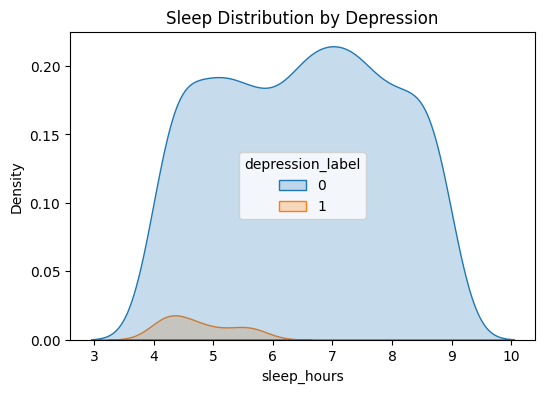

In [21]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='sleep_hours', hue='depression_label', fill=True)
plt.title("Sleep Distribution by Depression")
plt.show()



**Explanation**

- Non-depressed teens (label 0) show a wide, healthy distribution peaking at 5–7 hrs/night.
- Depressed teens (label 1) show a narrow, flat distribution concentrated at 3–5 hrs/night — indicating consistently poor sleep.
- Very few depressed teens sleep more than 6 hours, suggesting sleep deprivation is closely associated with depression in this dataset.

**Insight :**

Sleep duration is one of the most distinguishable features between the two groups. It may serve as a simple, accessible early-warning indicator for mental health risk.



2.  Social Media Usage vs Depression

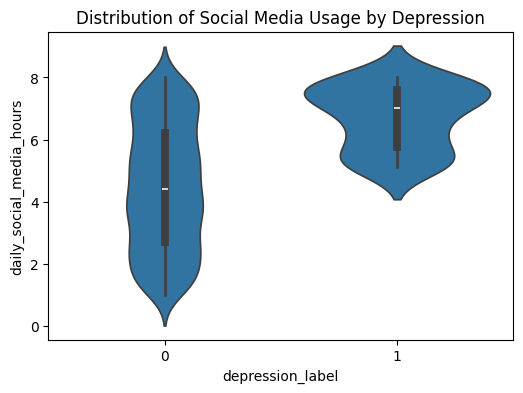

In [22]:
plt.figure(figsize=(6,4))
sns.violinplot(x='depression_label', y='daily_social_media_hours', data=df)
plt.title("Distribution of Social Media Usage by Depression")
plt.show()

Explanation

Depressed teens (label 1) average ~7 hrs/day with a tight, consistent distribution (6–8 hrs).
Non-depressed teens (label 0) average ~4–5 hrs/day with a much wider spread (0–9 hrs).
Users with < 3 hrs/day are almost exclusively non-depressed.
The overlap zone (4–9 hrs) means high usage alone cannot definitively indicate depression — it is a contributing signal, not a standalone predictor.
Insight:

Social media usage is a meaningful differentiating feature, but must be combined with other variables for reliable interpretation.

3.  Platform Usage v/s Depression

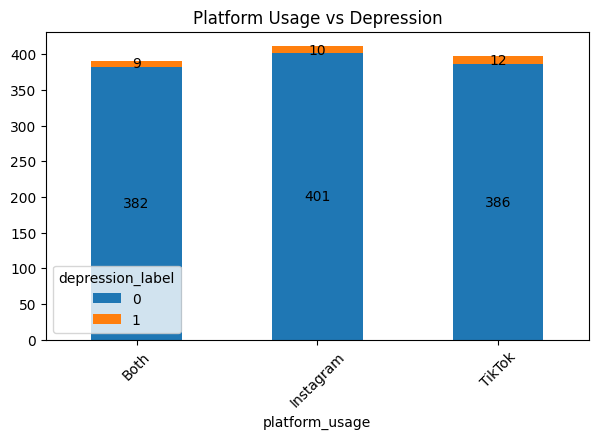

In [23]:
ct = pd.crosstab(df['platform_usage'], df['depression_label'])

ax = ct.plot(
    kind='bar',
    stacked=True,
    figsize=(7,4)
)

plt.title("Platform Usage vs Depression")
plt.xticks(rotation=45)

# Tambahkan label nominal
for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.show()


Explanation

1) Depression cases are minimal and evenly distributed across Instagram, TikTok, and Both platforms.
2) No single platform shows a notably higher proportion of depressed users.
Insight:

Platform type is NOT a key differentiating factor for depression. The risk comes from the duration and pattern of usage, not the platform itself. This finding suggests that intervention strategies should focus on screen time management rather than platform restriction.

# Correlation Analysis

Create: 
●  Correlation Heatmap

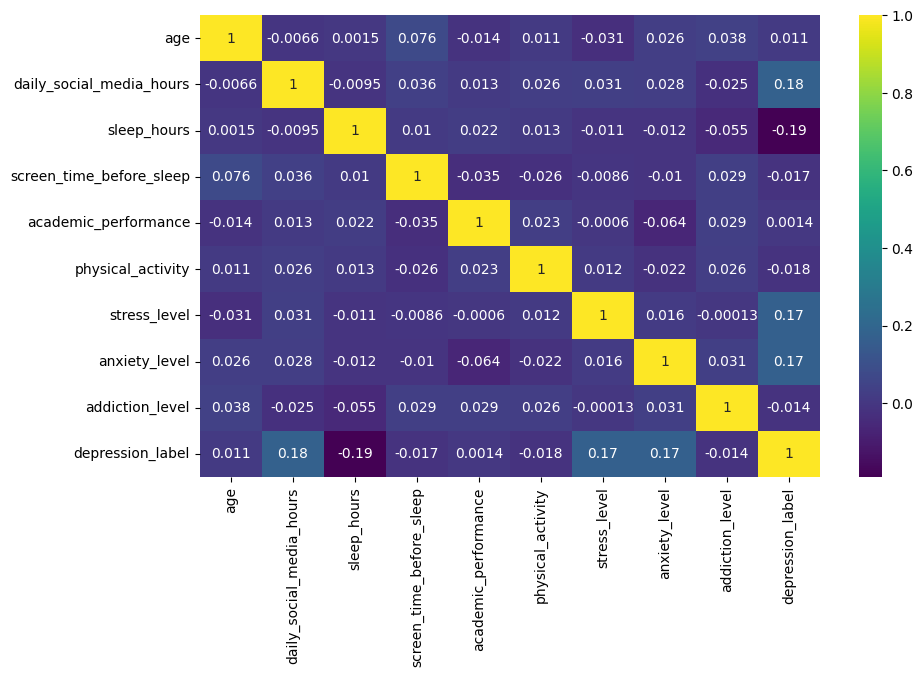

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='viridis')
plt.show()

In [25]:
corr = df.corr(numeric_only=True)

corr['depression_label'].sort_values(ascending=False)

depression_label            1.000000
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
age                         0.010973
academic_performance        0.001441
addiction_level            -0.013952
screen_time_before_sleep   -0.016502
physical_activity          -0.017598
sleep_hours                -0.190630
Name: depression_label, dtype: float64

 # Phase 4: Fetch Data


1.  High Screen Time

In [26]:
high_screen_time = (df['daily_social_media_hours'] > 5).sum()

print(f"There are {high_screen_time} Person how has more than 5 hour screen time")

There are 511 Person how has more than 5 hour screen time


2.  Low Sleep 


In [27]:
low_sleep = (df['sleep_hours'] < 6).sum()

print(f"There are {low_sleep} person how sleep less then 6 hour")

There are 480 person how sleep less then 6 hour


3. High Stress

In [28]:
high_stress = (df['stress_level'] > 7).sum()

print(f"There are {high_stress} how have high stress" )

There are 354 how have high stress


4. High Anxiety


In [29]:
high_anxiety = (df["anxiety_level" ]> 7).sum()

print(f"There are {high_anxiety} how have high anxiety" )

There are 385 how have high anxiety


# Phase 5 : Feature Encoding 

Task 

1. Select Categorical Column

In [30]:
cat_col = df.select_dtypes(include="object").columns
cat_col



Index(['gender', 'platform_usage', 'social_interaction_level'], dtype='str')

2. Encode the categorical column using LabelEncoder

In [31]:
from sklearn.preprocessing import LabelEncoder
lab_encoder = LabelEncoder()
for i in cat_col:
    df[i] = lab_encoder.fit_transform(df[i])

In [32]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0


# Phase 6 : Feature Selection 

In [33]:
x = df.iloc[ : , : -1]  # x = Independent column
y = df.iloc[ : , -1]   # y = dependent column

In [34]:
x

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,0,6.8,1,6.6,2.0,2.76,1.0,1,3,4,4
1196,16,1,2.3,0,8.0,1.9,2.12,0.4,0,7,4,4
1197,14,0,1.7,0,8.7,0.7,3.98,0.8,0,1,1,1
1198,15,1,3.9,0,8.5,2.1,3.19,0.6,0,7,9,9


In [35]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1195    0
1196    0
1197    0
1198    0
1199    0
Name: depression_label, Length: 1200, dtype: int64

# Phase 7 : Split the data into Test and Train 

In [36]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(x,y,test_size=0.3,
                                                       random_state=28,
                                                       stratify=y)

# Phase 8 : Class Imbalance Handling

Dataset Contains :

Not Depressed aprrox 97%
Depressed aprrox 3%

Task  :  

Apply : SMOTE 

SMOTE (Synthetic Minority Over-sampling Technique) is a popular machine learning algorithm used to handle imbalanced datasets.

In [37]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [39]:
print("Original Training Shape:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original Training Shape:
depression_label
0    818
1     22
Name: count, dtype: int64

After SMOTE:
depression_label
0    818
1    818
Name: count, dtype: int64


# Phase 9 :  Machine Learning Model Building

Use Random Forest Algorithm

In [40]:
from sklearn.ensemble import RandomForestClassifier

rfc_model = RandomForestClassifier()

In [41]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Stratified K-Fold Cross-Validation splits your dataset into equal parts to test a model's performance while keeping the percentage of each class identical across all splits. It is crucial for imbalanced data.Quick BreakdownStratification: Guarantees every split maintains the original dataset's class balance (e.g., 90% normal, 10% fraud).n_splits=5: Divides data into 5 parts, running 5 training loops where each part gets a turn as the testing set.shuffle=True: Randomizes row order before splitting to erase any underlying sorting biases.random_state=42: Locks the random seed so your exact data splits can be reproduced every time the code runs.

In [42]:
cv_scores = cross_val_score(
    rfc_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring='f1'
)

In [43]:
print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage F1 Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.9969419  0.99692308 1.         1.         1.        ]

Average F1 Score:
0.9987729945895083


 # Phase 10 :  Hyperparameter tuning

Use Hyperparameter tuning for best model performance

Hyperparameter tuning is the process of finding the optimal external settings for a machine learning model to maximize its performance.

Task : 

Apply :

GridSearchCV


In [44]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [45]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rfc_model,
    param_grid=param_grid,
    cv = cv,
    scoring='f1',
)

In [46]:
grid_search.fit(X_train_smote,y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation tim

In [47]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

Best F1 Score:
0.999388379204893


In [48]:
best_model = grid_search.best_estimator_

best_model.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [49]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

In [50]:
y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Phase 11 : Evaluation Metrics 

Task : 

1

Calculate: 
●  Accuracy 
●  Precision 
●  Recall 
●  F1 Score 
●  ROC-AUC


In [51]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,confusion_matrix
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

Accuracy Score:
0.9944444444444445
1.0
0.7777777777777778


In [52]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_pred,y_test)

0.9971671388101984

2. Plot heatmap of confusion matrix

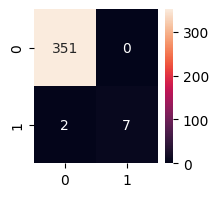

In [53]:
plt.figure(figsize=(2,2))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt = 'd')
plt.show()


# Phase 12 : Model Export 

Export Model Using Pickle in a file formate


In [54]:
import pickle 

with open("Teen_depression_Analysis_Model.pkl" , "wb") as file:
    pickle.dump(best_model,file)
    